# Page rank

In [62]:
import pandas as pd
import numpy as np
from scipy.sparse import coo_matrix, diags
import time
import matplotlib.pyplot as plt

edge_file = '../assignments/a1/data/facebook_large/musae_facebook_edges.csv'


## Read Dataset & Power Iteration

In [63]:
# 1. Load the graph into a Sparse Matrix
edges_df = pd.read_csv(edge_file)
sources = edges_df.iloc[:, 0].values
targets = edges_df.iloc[:, 1].values
N = max(sources.max(), targets.max()) + 1

# Create CSR matrix
data = np.ones(len(sources))
A = coo_matrix((data, (sources, targets)), shape=(N, N)).tocsr()
print(f"Graph loaded with {N} nodes and {A.nnz} edges.")

# 2. Power Iteration Implementation
def power_iteration(A, s, alpha=0.85, tol=1e-6, max_iter=100, track_errors=False):
    """
    Computes PageRank using the exact formulation from Section 3.4.1.

    Parameters:
    A (scipy.sparse.csr_matrix): Unweighted Adjacency matrix (N x N)
    s (numpy.ndarray): Teleportation / distribution vector (N x 1)
    alpha (float): Probability of following a random walk step
    tol (float): Threshold for the L1 norm stopping criterion
    max_iter (int): Maximum number of iterations to perform

    Returns:
    numpy.ndarray: The computed PageRank vector x
    """
    # 1. Build the row-stochastic matrix W
    # The out-degree of each node is the sum of its row in the adjacency matrix
    out_degrees = np.array(A.sum(axis=1)).flatten()

    # Handle "dangling nodes" (nodes with out-degree 0)
    # We temporarily set their degree to 1 to avoid division by zero when creating the inverse diagonal.
    # Note: In a strict mathematical sense, dangling nodes require an extra teleportation fix to keep W
    # perfectly row-stochastic, but this handles the matrix division safely.
    out_degrees[out_degrees == 0] = 1.0

    # Create the diagonal matrix of inverse out-degrees
    D_inv = diags(1.0 / out_degrees)

    # W is the row-stochastic random walk matrix: W = D_inv * A
    # The formula requires W transposed (W^T).
    # Using matrix properties: W^T = (D_inv * A)^T = A^T * D_inv
    W_T = A.T.dot(D_inv)

    # 2. Initialization
    # As suggested in the text, we pick our initial guess x_0 to be the vector s
    x = s.copy()
    errors = []

    # 3. Power Iteration Loop
    for k in range(1, max_iter + 1):
        # Store x_{k-1}
        x_prev = x.copy()

        # Apply the exact update rule: x_k = (1 - alpha)s + alpha * W^T * x_{k-1}
        x = (1 - alpha) * s + alpha * W_T.dot(x_prev)

        # 4. Stopping Criterion
        # Check if the L1 norm ||x_k - x_{k-1}||_1 is below the threshold
        diff_norm = np.linalg.norm(x - x_prev, 1)
        if track_errors:
            errors.append(diff_norm)

        if diff_norm <= tol:
            print(f"Power iteration converged after {k} iterations (Error: {diff_norm:.2e}).")
            break
    else:
        print(f"Warning: Reached {max_iter} iterations without satisfying the threshold.")
    if track_errors:
        return x, errors
    return x

Graph loaded with 22470 nodes and 171002 edges.


## Part 4: Standard PageRank (Top 50 Nodes)

In [64]:
# Create uniform teleportation vector s
s_uniform = np.ones(N) / N

# Run PageRank
pagerank_scores = power_iteration(A, s=s_uniform, alpha=0.85)

# Get the indices of the top 50 nodes
top_50_indices = np.argsort(pagerank_scores)[::-1][:50]

# Try to load node names (assumes target.csv is in the same directory as edge.csv)
target_file = edge_file.replace('edges.csv', 'target.csv')
try:
    targets_df = pd.read_csv(target_file)
    id_to_name = dict(zip(targets_df['id'], targets_df['page_name']))
    print("Top 50 Most Important Nodes by Name:")
    for idx in top_50_indices:
        print(f"Score: {pagerank_scores[idx]:.6f} | Name: {id_to_name.get(idx, f'Node {idx}')}")
except FileNotFoundError:
    print("Could not find target.csv to extract names. Printing IDs instead:")
    print(top_50_indices)

Power iteration converged after 16 iterations (Error: 3.48e-07).
Top 50 Most Important Nodes by Name:
Score: 0.002138 | Name: The Obama White House
Score: 0.001207 | Name: U.S. Department of State: Consular Affairs
Score: 0.001014 | Name: Microsoft
Score: 0.000993 | Name: City of Los Altos Police Department
Score: 0.000864 | Name: The Connecticut National Guard
Score: 0.000860 | Name: Federica Mogherini
Score: 0.000845 | Name: NHTSA
Score: 0.000769 | Name: Joachim Herrmann
Score: 0.000657 | Name: Dr. Hedy Fry
Score: 0.000651 | Name: Digicel
Score: 0.000623 | Name: The White House
Score: 0.000571 | Name: Israel in the UK
Score: 0.000549 | Name: 21st Theater Sustainment Command
Score: 0.000533 | Name: Katarina Barley
Score: 0.000523 | Name: Royal Navy
Score: 0.000515 | Name: Bruce Notley-Smith MP
Score: 0.000513 | Name: Frans Timmermans
Score: 0.000509 | Name: Baltimore District, U.S. Army Corps of Engineers
Score: 0.000494 | Name: Chobani
Score: 0.000475 | Name: Jean-Claude Juncker
Scor

### Findings

Everything is connected to Obama White House. Overall the most important sides are US political sides or big tech.

## Part 5: Personalized PageRank (PPR)

In [96]:
# Select an interesting node (e.g., node 0)
v = np.random.randint(0, N)
s_v = np.zeros(N)
s_v[v] = 1.0

ppr_scores = power_iteration(A, s=s_v, alpha=0.85)
top_10_ppr = np.argsort(ppr_scores)[::-1][:10]

name = id_to_name.get(v, f"Node {v}")
print(f"\nTop 10 nodes for Personalized PageRank from Node {name}:")
for idx in top_10_ppr:
    # Use id_to_name if available from Part 4
    name = id_to_name.get(idx, f"Node {idx}") if 'id_to_name' in locals() else f"Node {idx}"
    print(f"Score: {ppr_scores[idx]:.6f} | Name: {name}")

Power iteration converged after 12 iterations (Error: 0.00e+00).

Top 10 nodes for Personalized PageRank from Node Ambassade du Canada en Allemagne:
Score: 0.150000 | Name: Ambassade du Canada en Allemagne
Score: 0.057022 | Name: Consulat général du Canada à Miami
Score: 0.054313 | Name: La politique étrangère du Canada – Affaires mondiales Canada
Score: 0.031875 | Name: Haut commissariat du Canada au Royaume uni
Score: 0.031875 | Name: Bureau des droits de la personne, des libertés et de l’inclusion du Canada
Score: 0.018062 | Name: Canada aux EAU
Score: 0.009666 | Name: Haut-commissariat du Canada à Trinité et Tobago
Score: 0.009666 | Name: Ambassade du Canada en Indonésie et au Timor-Leste
Score: 0.009666 | Name: Ambassade du Canada en Israël
Score: 0.009031 | Name: Embassy of Canada to Germany


### Findings
Often the number one pick is the first and after that other connected pages show up. e.g. Australian politicians are relevant for other Australian positions.

If we would know the users preferences I could weight them accordingly and init the s to the exact preferences.

## Part 6: Explore the Impact of $\alpha$

In [98]:
import time
import matplotlib.pyplot as plt

print("\n--- Measuring Run Time and Iterations for Different Alphas ---")

alphas_to_test = [0.1, 0.3, 0.5, 0.7, 0.85, 0.95, 0.99]
run_times = []
all_errors = {}  # Dictionary to store the error lists for each alpha

for alpha_val in alphas_to_test:
    # Start the timer
    start_time = time.time()

    # Run the textbook function with error tracking enabled
    # Assuming your function is named power_iteration_textbook as defined earlier
    scores, errors = power_iteration(A, s=s_uniform, alpha=alpha_val, track_errors=True)

    top_10_ppr = np.argsort(scores)[::-1][:10]
    name = id_to_name.get(v, f"Node {v}")
    print(f"\nTop 10 nodes for Personalized PageRank with alpha {alpha_val}:")
    for idx in top_10_ppr:
        # Use id_to_name if available from Part 4
        name = id_to_name.get(idx, f"Node {idx}") if 'id_to_name' in locals() else f"Node {idx}"
        print(f"Score: {scores[idx]:.6f} | Name: {name}")

    # Stop the timer
    end_time = time.time()
    elapsed_time = end_time - start_time

    run_times.append(elapsed_time)
    all_errors[alpha_val] = errors  # Save the errors to plot later

    print(f"Alpha = {alpha_val:.2f} | Iterations: {len(errors):>3} | Time: {elapsed_time:.4f} seconds")


--- Measuring Run Time and Iterations for Different Alphas ---
Power iteration converged after 6 iterations (Error: 7.30e-08).

Top 10 nodes for Personalized PageRank with alpha 0.1:
Score: 0.000333 | Name: Joachim Herrmann
Score: 0.000320 | Name: The Obama White House
Score: 0.000294 | Name: Sir Peter Bottomley MP
Score: 0.000219 | Name: The White House
Score: 0.000207 | Name: Katarina Barley
Score: 0.000206 | Name: U.S. Army Chaplain Corps
Score: 0.000195 | Name: U.S. Army
Score: 0.000188 | Name: FEMA Federal Emergency Management Agency
Score: 0.000166 | Name: Dr. Hedy Fry
Score: 0.000154 | Name: Manfred Weber
Alpha = 0.10 | Iterations:   6 | Time: 0.0068 seconds
Power iteration converged after 9 iterations (Error: 1.55e-07).

Top 10 nodes for Personalized PageRank with alpha 0.3:
Score: 0.001002 | Name: The Obama White House
Score: 0.000807 | Name: Joachim Herrmann
Score: 0.000644 | Name: Sir Peter Bottomley MP
Score: 0.000548 | Name: The White House
Score: 0.000484 | Name: Katarin

### Findings
Lower alpha find results faster but the bigger

## Part 7: Plot Convergence

### Findings
with a low alpha we mostly do random jumps and don't seem to have too connected nodes. With a high alpha we jump almost never and therefore find results that are extreme close together.

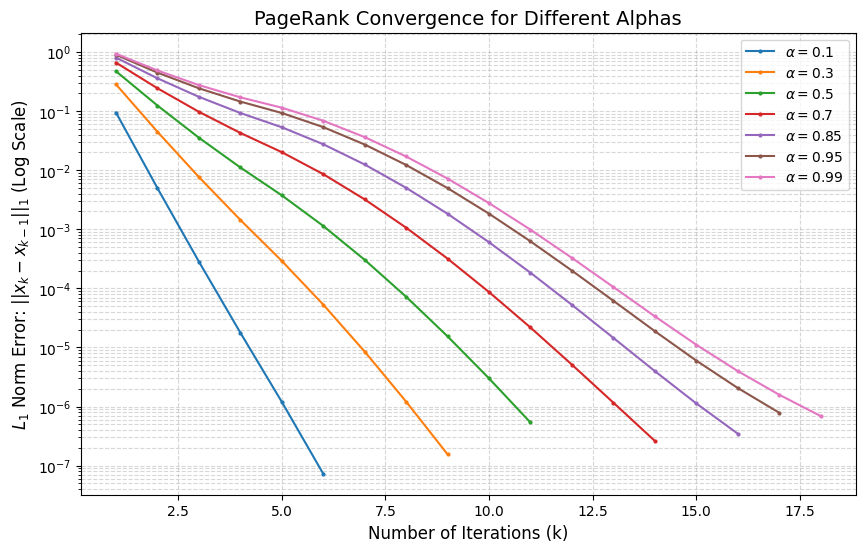

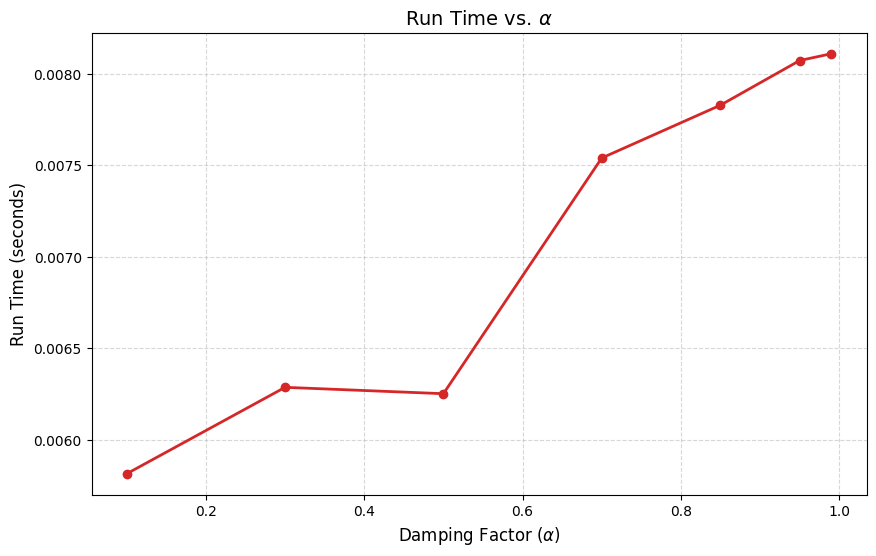

In [89]:
# ==========================================
# PLOT 1: Convergence over Iterations
# ==========================================
plt.figure(figsize=(10, 6))

# Plot the error line for each alpha
for alpha_val in alphas_to_test:
    iterations = range(1, len(all_errors[alpha_val]) + 1)
    plt.plot(iterations, all_errors[alpha_val], marker='.', markersize=4, linestyle='-', label=rf'$\alpha = {alpha_val}$')

plt.yscale('log')
plt.xlabel('Number of Iterations (k)', fontsize=12)
plt.ylabel(r'$L_1$ Norm Error: $||x_k - x_{k-1}||_1$ (Log Scale)', fontsize=12)
plt.title('PageRank Convergence for Different Alphas', fontsize=14)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=10)
plt.show() # Display the first plot


# ==========================================
# PLOT 2: Run Time vs Alpha
# ==========================================
plt.figure(figsize=(10, 6))

plt.plot(alphas_to_test, run_times, marker='o', color='tab:red', linewidth=2)
plt.xlabel(r'Damping Factor ($\alpha$)', fontsize=12)
plt.ylabel('Run Time (seconds)', fontsize=12)
plt.title(r'Run Time vs. $\alpha$', fontsize=14)
plt.grid(True, alpha=0.5, linestyle='--')
plt.show() # Display the second plot completely separate from the first

### Findings
The higher the alpha the slower the error decreases and therefore we need more interations until it converges. And the runtime increases with number of iterations.